# Chapter 3, Exercise 3: A log-mel and MFCC pipeline from scratch

> **How to use this notebook.** Open it in Google Colab (File > Upload notebook, or the Colab badge on the companion website), then run the cells from top to bottom. Runtime > Change runtime type lets you pick a GPU when one is recommended below. Everything else runs on the free CPU tier.

## The exercise

**Chapter 3, Exercise 3.** Build a basic feature-extraction pipeline in Python that takes raw 16 kHz audio and outputs 40-dimensional log-mel vectors. Give the size after each stage from raw samples to the log-mel matrix, say where you would continue to obtain 13 MFCCs, and compare your output against a standard toolkit. State whether your pipeline uses the magnitude or power spectrum and whether the zeroth coefficient is kept.

## Requirements

No GPU is required; the notebook runs on Colab's free CPU runtime.


In [1]:
!pip install -q librosa soundfile numpy scipy matplotlib

## 1. Get one second of 16 kHz audio

By default the notebook synthesizes a one-second vowel-like signal so that it runs anywhere. To use a real Arabic clip (for example one Common Voice or FLEURS file, or your own recording), set `USE_UPLOAD = True` and upload a WAV; it will be resampled to 16 kHz if needed.

In [2]:
import numpy as np, soundfile as sf, librosa, matplotlib.pyplot as plt
FS = 16_000
USE_UPLOAD = False
if USE_UPLOAD:
    try:
        from google.colab import files
        name = list(files.upload().keys())[0]
    except ImportError:
        name = "clip.wav"
    y, sr = sf.read(name)
    if y.ndim > 1: y = y.mean(axis=1)
    if sr != FS: y = librosa.resample(y.astype(np.float32), orig_sr=sr, target_sr=FS)
    y = y[:FS]                                   # keep exactly one second for the size table
else:
    # synthetic one-second signal: a glottal pulse train through three resonances, plus mild noise
    from scipy import signal
    t = np.arange(FS)/FS
    src = np.zeros(FS); src[::int(FS/130)] = 1.0
    src = signal.lfilter([1], [1, -0.97], src)
    y = src.copy()
    for fc, bw in [(500, 80), (1500, 100), (2500, 160)]:
        r = np.exp(-np.pi*bw/FS); th = 2*np.pi*fc/FS
        y = signal.lfilter([1 - 2*r*np.cos(th) + r*r], [1, -2*r*np.cos(th), r*r], y)
    y = y/np.abs(y).max()*0.8 + 0.005*np.random.default_rng(0).normal(size=FS)
y = y.astype(np.float32)
print("Stage 0  raw waveform:", y.shape, "samples  (1 s at 16 kHz)")

Stage 0  raw waveform: (16000,) samples  (1 s at 16 kHz)


## 2. The pipeline, stage by stage

Settings (Table 3.3): frame 25 ms = 400 samples zero-padded to 512 (Figure 3.7), hop 10 ms = 160 samples, Hamming window, 512-point FFT, **power** spectrum, 40 triangular mel filters between 0 Hz and 8 kHz using the **Slaney** mel convention with no filter normalization (`librosa` defaults, `htk=False, norm=None`), natural logarithm with a floor of 1e-10, no pre-emphasis, no centering (the first frame starts at sample 0 and the final incomplete frame is dropped).

In [3]:
FRAME, HOP, NFFT, N_MELS = 400, 160, 512, 40

# Stage 1: framing. Each analysis frame holds 400 signal samples (25 ms); to make the FFT size 512 we
# zero-pad 56 samples on each side, which is exactly what librosa does when win_length < n_fft
# (the window is centred inside the n_fft frame). We therefore step a 512-sample frame along the
# signal and remember that only its central 400 samples are weighted by the window.
n_frames = 1 + (len(y) - NFFT)//HOP
idx = np.arange(NFFT)[None, :] + HOP*np.arange(n_frames)[:, None]
frames = y[idx]
print("Stage 1  frames:", frames.shape, "(frames x FFT-length samples; 400 of the 512 are inside the window)")

# Stage 2: windowing with a 400-point Hamming window centred in the 512-sample frame
PAD = (NFFT - FRAME)//2
from scipy.signal import get_window
win = np.zeros(NFFT); win[PAD:PAD+FRAME] = get_window('hamming', FRAME, fftbins=True)   # periodic Hamming, the STFT convention
frames_w = frames * win
print("Stage 2  windowed frames:", frames_w.shape, "(effective frame = 400 samples, zero-padded to 512)")

# Stage 3: FFT and one-sided POWER spectrum
spec = np.fft.rfft(frames_w, n=NFFT)            # complex, 257 bins
power = np.abs(spec)**2                          # |X|^2 : power spectrum
print("Stage 3  power spectrum:", power.shape, "(frames x (NFFT/2+1) bins), bin spacing =", FS/NFFT, "Hz")

# Stage 4: mel filterbank (Slaney scale, no normalization), applied to the power spectrum
mel_fb = librosa.filters.mel(sr=FS, n_fft=NFFT, n_mels=N_MELS, fmin=0.0, fmax=FS/2, htk=False, norm=None)
print("         mel filterbank matrix:", mel_fb.shape, "(mels x bins)")
mel_energy = power @ mel_fb.T
print("Stage 4  mel energies:", mel_energy.shape)

# Stage 5: logarithm
logmel = np.log(np.maximum(mel_energy, 1e-10))
print("Stage 5  log-mel matrix:", logmel.shape, "(frames x 40)  <- the output of the pipeline")

Stage 1  frames: (97, 512) (frames x FFT-length samples; 400 of the 512 are inside the window)
Stage 2  windowed frames: (97, 512) (effective frame = 400 samples, zero-padded to 512)
Stage 3  power spectrum: (97, 257) (frames x (NFFT/2+1) bins), bin spacing = 31.25 Hz


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


         mel filterbank matrix: (40, 257) (mels x bins)
Stage 4  mel energies: (97, 40)
Stage 5  log-mel matrix: (97, 40) (frames x 40)  <- the output of the pipeline


### Size table for one second of 16 kHz audio

| Stage | Operation | Size |
|---|---|---|
| 0 | raw samples | 16,000 |
| 1 | framing (25 ms = 400 samples, hop 10 ms = 160 samples, zero-padded to 512, no centering) | 97 frames x 512 samples (400 inside the window) |
| 2 | Hamming window (400 points, periodic form as used by STFT toolkits) | 97 x 512 |
| 3 | 512-point FFT, one-sided power spectrum | 97 x 257 |
| 4 | 40-filter mel filterbank | 97 x 40 |
| 5 | log | **97 x 40 log-mel** |
| 6 (optional) | DCT-II, keep 13 coefficients | 97 x 13 MFCC |
| 7 (optional) | append delta and delta-delta | 97 x 39 |

The frame count depends on the framing convention: 1 + (16000 - 512)/160 = 97 here; a pipeline that pads the last partial frame, or centres frames on the signal (librosa `center=True`), gives 98 or 101. Table 3.3 asks you to report this. The book's rule of thumb "about 100 frames per second" covers all of them.

In [4]:
# Stage 6 (where MFCCs would continue): DCT-II (orthonormal) over the 40 log-mel values, keep 13
from scipy.fftpack import dct
mfcc = dct(logmel, type=2, axis=1, norm='ortho')[:, :13]
print("Stage 6  MFCC:", mfcc.shape, "(coefficient 0 is KEPT; it summarizes overall log energy)")
delta = librosa.feature.delta(mfcc.T, order=1).T; delta2 = librosa.feature.delta(mfcc.T, order=2).T
print("Stage 7  MFCC + delta + delta-delta:", np.hstack([mfcc, delta, delta2]).shape)

Stage 6  MFCC: (97, 13) (coefficient 0 is KEPT; it summarizes overall log energy)
Stage 7  MFCC + delta + delta-delta: (97, 39)


## 3. Compare with a standard toolkit (librosa)

`librosa.feature.melspectrogram` with the same settings should reproduce Stage 4 exactly, and `librosa.feature.mfcc` on the log of it should reproduce Stage 6. The toolkit's default log is `power_to_db` (10 log10), so we take the natural log ourselves to match.

librosa mel energies: (97, 40)
max |ours - librosa| on mel energies: 0.00022041785246074141
max |ours - librosa| on log-mel: 4.678781513334229e-07
max |ours - librosa| on 13 MFCCs (c0 kept in both): 2.787160489958751e-06


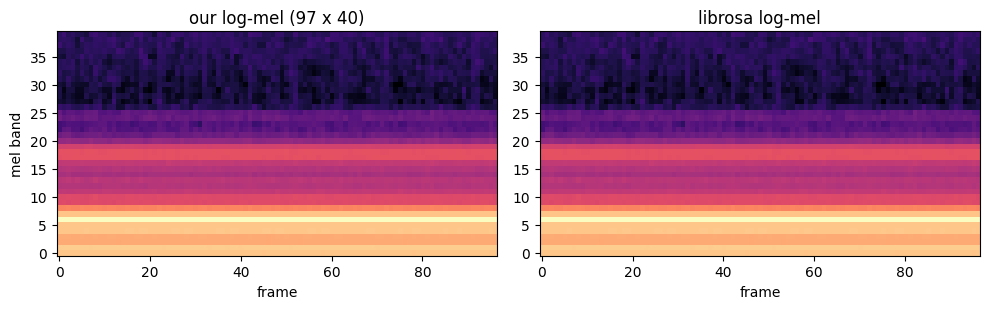

In [5]:
mel_lib = librosa.feature.melspectrogram(y=y, sr=FS, n_fft=NFFT, hop_length=HOP, win_length=FRAME,
                                         window='hamming', center=False, power=2.0,
                                         n_mels=N_MELS, fmin=0.0, fmax=FS/2, htk=False, norm=None).T
print("librosa mel energies:", mel_lib.shape)
print("max |ours - librosa| on mel energies:", np.abs(mel_energy - mel_lib).max())
logmel_lib = np.log(np.maximum(mel_lib, 1e-10))
print("max |ours - librosa| on log-mel:", np.abs(logmel - logmel_lib).max())

mfcc_lib = librosa.feature.mfcc(S=logmel_lib.T, n_mfcc=13, dct_type=2, norm='ortho').T
print("max |ours - librosa| on 13 MFCCs (c0 kept in both):", np.abs(mfcc - mfcc_lib).max())

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].imshow(logmel.T, origin='lower', aspect='auto', cmap='magma'); ax[0].set_title('our log-mel (97 x 40)')
ax[1].imshow(logmel_lib.T, origin='lower', aspect='auto', cmap='magma'); ax[1].set_title('librosa log-mel')
for a in ax: a.set_xlabel('frame'); ax[0].set_ylabel('mel band')
plt.tight_layout(); plt.show()

## 4. Statement of choices

* **Spectrum type:** the pipeline uses the **power spectrum** (|X|²), the convention of Kaldi and librosa (`power=2.0`); HTK-style pipelines use the magnitude spectrum, which changes the log-mel values by a factor of two in the log domain but not the shape.
* **Zeroth coefficient:** **kept** (13 coefficients c0 to c12). Many classical recipes replace c0 with log energy or drop it; report which.
* **Mel convention:** Slaney (librosa default); HTK's formula places the filters slightly differently, so a comparison with an HTK-style toolkit (torchaudio's `MelSpectrogram` uses HTK by default) will differ unless `htk=True` is set.
* The agreement with librosa is at floating-point precision when every one of these settings is matched, which is the practical demonstration of why Table 3.3 asks for all of them.